In [1]:
# Darstellung anpassen

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))



In [2]:
# Lade benötigte Programmpakete

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import sklearn as sk

In [3]:
from sklearn.datasets import fetch_openml # Lade den MNIST_784-Datensatz
mnist=fetch_openml('mnist_784',as_frame=False,parser='auto')

In [18]:
X=mnist['data'] # Features, 
y=mnist['target'] # Labels
print(f"Shape of X: {X.shape}")
# Teile in Trainings und Test-Daten. Verwende die ersten 60000 Bilder zum trainieren und die letzten 10000 zum Testen
X_train=X[:2000,:]
y_train=y[:2000]
X_test=X[60000:,:]
y_test=y[60000:]



Shape of X: (70000, 784)


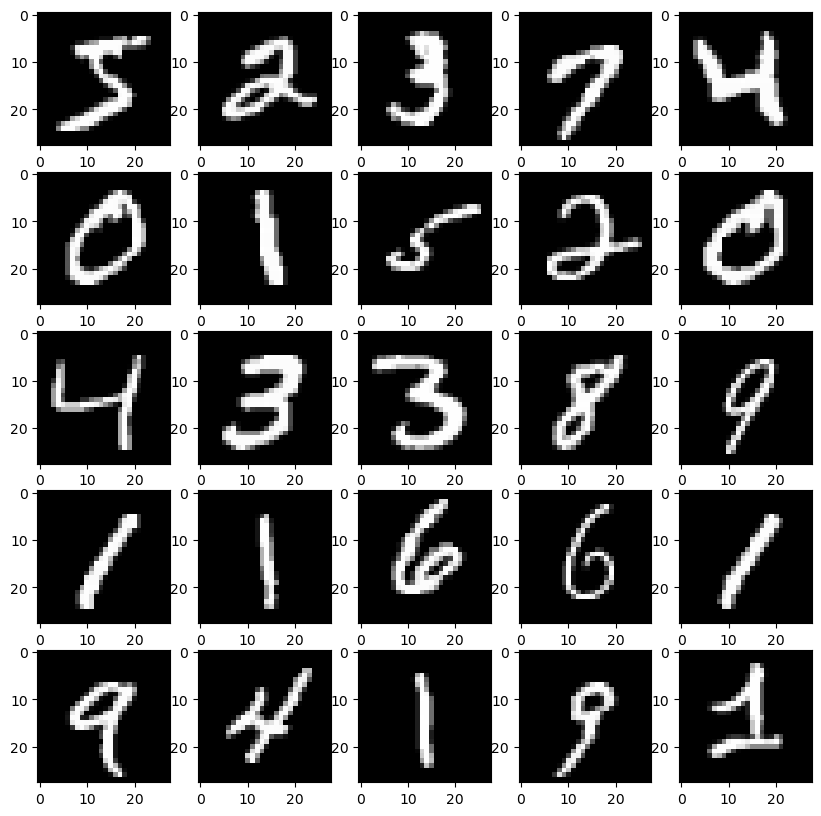

In [19]:
# Plotte Beispielbilder der Ziffern
fig,ax=plt.subplots(5,5,figsize=(10,10))
for i in range(25):
    j=i%5
    k=i//5

    test_image=X[i].reshape(28,28)
    ax[j,k].imshow(test_image,cmap='gray',vmin=0, vmax=255)

##### Entwickeln Sie einen Classifier der die Ziffer '5' erkennt. Verwenden Sie zur Entwicklung den Trainingsdatensatz X_train, y_train und verwenden Sie die in der LV besprochenen Methoden um ein optimales Modell mit optimalen Hyperparametern zu entwickeln. Erst wenn Sie fertig sind, und überzeugt das bestmögliche Modell gefunden zu haben, Werten Sie ihre Daten am Test-Datensatz aus. 

In [22]:
# Preprocsessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
print(scaler.fit(X_train))
print(scaler.data_max_)
print(scaler.transform(X_train))
X_train_scaled = scaler.transform(X_train)

MinMaxScaler()
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  20. 124.  90. 219.
 224. 209. 255. 255. 253. 189. 218. 206. 142.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   7. 139. 255. 239. 232. 228. 254.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 206.  93.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  67. 244. 253. 254. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 231. 117.   0.   0.   0.
   0.   0.   0.   0.  45. 141. 219. 252. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 236. 116.   0.   0.
   0.   0.   0. 255. 253. 254. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 234.  82.   0.
   0.   0.   0. 138. 254. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 254. 1

In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, KFold
# Creating a support vector classifier
svc=SVC() # probability=True

gammas = np.logspace(1,3, 5)

gs = GridSearchCV(svc, {'gamma': gammas}, cv=KFold(n_splits=5), scoring = "neg_mean_squared_error", return_train_score=True, verbose=3, n_jobs=-1)
gs.fit(X_train_scaled, y_train)

#svc.fit(X_train_scaled, y_train)
print(gs.best_params_)
print("Accuracy on training set: {:.3f}".format(gs.best_score_))
#print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'gamma': np.float64(10.0)}
Accuracy on training set: -17.253
